# Task
Train a neural network to classify images from the Fashion MNIST dataset.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


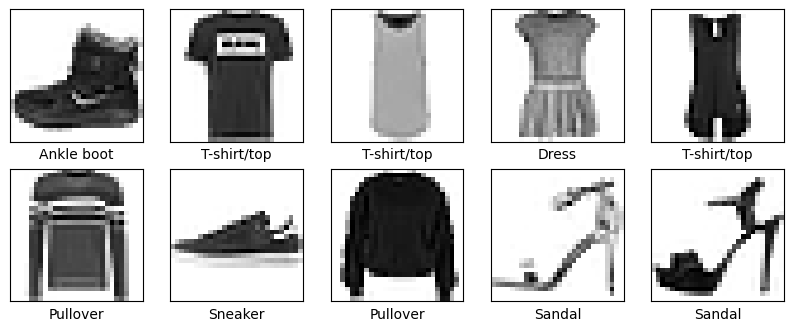

In [ ]:
import matplotlib.pyplot as plt

# Define class names for Fashion MNIST for better readability
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Create a figure and a set of subplots
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(5, 5, i + 1) # Adjust subplot grid as needed
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()


In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

print(f"x_train shape after normalization: {x_train.shape}")
print(f"y_train shape after one-hot encoding: {y_train.shape}")
print(f"x_test shape after normalization: {x_test.shape}")
print(f"y_test shape after one-hot encoding: {y_test.shape}")

x_train shape after normalization: (60000, 28, 28)
y_train shape after one-hot encoding: (60000, 10)
x_test shape after normalization: (10000, 28, 28)
y_test shape after one-hot encoding: (10000, 10)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Build the neural network model
model = Sequential([
    Flatten(input_shape=(28, 28)), # Input layer to flatten 28x28 images to 784 pixels
    Dense(128, activation='relu'), # Hidden layer with 128 neurons and ReLU activation
    Dense(64, activation='relu'),  # Second hidden layer with 64 neurons and ReLU activation
    Dense(10, activation='softmax') # Output layer with 10 neurons (for 10 classes) and Softmax activation
])

print("Neural network model constructed.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Neural network model constructed.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Build the neural network model
model = Sequential([
    tf.keras.Input(shape=(28, 28)), # Explicit Input layer to define the input shape
    Flatten(), # Flatten will now infer the shape from the Input layer
    Dense(128, activation='relu'), # Hidden layer with 128 neurons and ReLU activation
    Dense(64, activation='relu'),  # Second hidden layer with 64 neurons and ReLU activation
    Dense(10, activation='softmax') # Output layer with 10 neurons (for 10 classes) and Softmax activation
])

print("Neural network model constructed.")

Neural network model constructed.


In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
import datetime
from tensorflow.keras.callbacks import TensorBoard

# Define the TensorBoard log directory
log_dir = "./logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

print(f"TensorBoard log directory set to: {log_dir}")

TensorBoard log directory set to: ./logs/fit/20260119-182147


In [ ]:
history = model.fit(x_train, y_train,
                    epochs=10,
                    validation_data=(x_test, y_test),
                    callbacks=[tensorboard_callback])

print("Model training complete.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7800 - loss: 0.6283 - val_accuracy: 0.8481 - val_loss: 0.4199
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8631 - loss: 0.3738 - val_accuracy: 0.8535 - val_loss: 0.4022
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8741 - loss: 0.3362 - val_accuracy: 0.8696 - val_loss: 0.3624
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8873 - loss: 0.3095 - val_accuracy: 0.8640 - val_loss: 0.3836
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.8900 - loss: 0.2936 - val_accuracy: 0.8719 - val_loss: 0.3569
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8973 - loss: 0.2739 - val_accuracy: 0.8809 - val_loss: 0.3392
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9009 - loss: 0.2659 - val_accuracy: 0.8800 - val_loss: 0.3305
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9061 - loss: 0

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [ ]:
final_train_accuracy = history.history['accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

Final Training Accuracy: 0.9108
Final Training Loss: 0.2363
Final Validation Accuracy: 0.8852
Final Validation Loss: 0.3332
